In [1]:
from gtfs_railways.functions.core import load_gtfs
from gtfs_railways.functions.core import load_graph
from gtfs_railways.functions.core import save_graph
from gtfs_railways.functions.core import compute_time
from gtfs_railways.functions.core import plot_efficiency_results
from gtfs_railways.functions.core import simulate_fixed_node_removal_efficiency
from gtfs_railways.functions.core import make_sp_func

from gtfs_railways.functions.v4 import get_all_GTC as get_all_GTC_v4, P_space as P_space_v4

In [2]:
import sys
from pathlib import Path

path_to_your_local_folder = Path("C:/Users/KIIT/Documents/UAntwerp/gtfs_railways")
sys.path.append(str(path_to_your_local_folder))

In [3]:
L_graph = load_graph(path_to_your_local_folder / "examples/data/belgium_Lspace.pkl")
P_graph = load_graph(path_to_your_local_folder / "examples/data/belgium_Pspace.pkl")
attributes = load_gtfs(str(path_to_your_local_folder / "examples/data/belgium.sqlite"))

Random removal order: [114, 25, 281, 250, 228]
Original Efficiency: 0.007892688205220577
Removed edges of 114 → Normalized Efficiency: 0.9564
Time taken: 65.5815 seconds

Removed edges of 25 → Normalized Efficiency: 0.8994
Time taken: 61.9690 seconds

Removed edges of 281 → Normalized Efficiency: 0.8881
Time taken: 61.6347 seconds

Removed edges of 250 → Normalized Efficiency: 0.8724
Time taken: 61.7559 seconds

Removed edges of 228 → Normalized Efficiency: 0.8368
Time taken: 62.4152 seconds

Function 'simulate_fixed_node_removal_efficiency' completed.
Execution time: 380.90 seconds



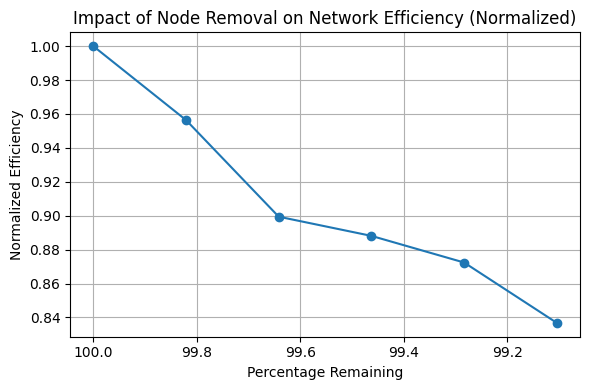

In [4]:
simulate_fixed_node_removal_efficiency = compute_time(simulate_fixed_node_removal_efficiency) # time decorator

sp_func = make_sp_func(attributes, get_all_GTC_v4, P_space_v4)

original_efficiency, efficiencies, num_removed, removed_nodes, removal_times = \
    simulate_fixed_node_removal_efficiency(
        L_graph=L_graph,
        sp_func=sp_func,
        num_to_remove=5,
        method='random',
        seed=42,
        verbose=True
    )

# Plot results
plot_efficiency_results(num_removed, efficiencies)